# WM Prediction 2026 – Version 3

Erweiterungen gegenüber Version 2:

| Feature | Beschreibung |
|---|---|
| **Elo + Torabstand-Bonus** | Margin-of-Victory-Multiplikator: höhere K-Faktoren bei klaren Siegen |
| **Form der letzten 5 Spiele** | Gewichtete Punktzahl je Team als zusätzliches Modell-Feature |
| **Dixon-Coles-Korrektur** | Korrigiert die Poisson-Unabhängigkeit bei Niedrigtoren (0:0, 1:0, 0:1, 1:1) |

**Architektur (unverandert):**
- `all_matches` – alle Spiele seit 1872 → Elo-Berechnung
- `model_matches` – letzte 20 Jahre → Poisson-Training + Form-Feature

> Da bei einer WM alle Spiele auf neutralem Boden stattfinden, wird kein Heimvorteil modelliert.

## 1 · Setup

In [25]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict, deque
import matplotlib.pyplot as plt

## 2 · Daten laden

- `all_matches` – gesamter Datensatz (1872–heute), **nur für Elo**
- `model_matches` – letzte 20 Jahre, **für Poisson-Modell und Form-Feature**

In [26]:
RESULTS_FILE = "results.csv"

all_matches = pd.read_csv(RESULTS_FILE)
all_matches['date'] = pd.to_datetime(all_matches['date'])
all_matches = all_matches.sort_values('date').reset_index(drop=True)

cutoff = pd.Timestamp.now() - pd.DateOffset(years=20)
model_matches = all_matches[all_matches['date'] >= cutoff].copy()

print(f"Gesamt-Datensatz  (Elo):     {len(all_matches):>6} Spiele  "
      f"({all_matches['date'].dt.year.min()}–{all_matches['date'].dt.year.max()})")
print(f"Modell-Datensatz  (Poisson): {len(model_matches):>6} Spiele  "
      f"({model_matches['date'].dt.year.min()}–{model_matches['date'].dt.year.max()})")

Gesamt-Datensatz  (Elo):      49378 Spiele  (1872–2026)
Modell-Datensatz  (Poisson):  19345 Spiele  (2006–2026)


## 3 · Elo-Berechnung mit Torabstand-Bonus (gesamter Datensatz)

### Torabstand-Multiplikator
Klare Siege werden stärker gewichtet als knappe – analog zu Club-Elo und FIFA-Ranking:

$$m = \ln(\Delta g + 1) \cdot \frac{2.2}{\Delta E \cdot 0.001 + 2.2}$$

- $\Delta g$ = Tordifferenz (gecapped bei 1 für Unentschieden)
- $\Delta E$ = Elo-Differenz des Siegers vor dem Spiel (verhindert Inflation bei Favoritensiegen)
- Der zweite Term dämpft den Bonus wenn der Stärkere gewinnt

In [27]:
def get_k_factor(tournament):
    t = str(tournament)
    if t == "FIFA World Cup":            return 60
    if "UEFA Euro" in t:                 return 50
    if "Copa América" in t:              return 50
    if "African Cup of Nations" in t:    return 50
    if "AFC Asian Cup" in t:             return 50
    if "OFC Nations Cup" in t:           return 50
    if "Nations League" in t:            return 40
    if "qualification" in t.lower():     return 30
    if "Friendly" in t:                  return 15
    return 25


def mov_multiplier(goal_diff, elo_diff_winner):
    """Margin-of-Victory Multiplikator (goal_diff >= 0, elo_diff_winner >= 0)."""
    if goal_diff == 0:
        return 1.0
    return np.log(goal_diff + 1) * (2.2 / (elo_diff_winner * 0.001 + 2.2))


In [28]:
INITIAL_ELO = 1500
elo = {}

def get_elo(team):
    return elo.get(team, INITIAL_ELO)


elo_home_before = []
elo_away_before = []
current_year = None

for _, row in all_matches.iterrows():

    year = row['date'].year

    # Elo-Decay: 2 % Rückkehr Richtung Mittelwert pro Jahr
    if current_year is None:
        current_year = year
    if year > current_year:
        for team in elo:
            elo[team] = INITIAL_ELO + (elo[team] - INITIAL_ELO) * 0.98
        current_year = year

    home = row['home_team']
    away = row['away_team']
    eh   = get_elo(home)
    ea   = get_elo(away)

    elo_home_before.append(eh)
    elo_away_before.append(ea)

    expected_home = 1 / (1 + 10 ** ((ea - eh) / 400))

    hs, as_ = row['home_score'], row['away_score']
    goal_diff = abs(hs - as_)

    if hs > as_:
        actual_home = 1.0
        mov = mov_multiplier(goal_diff, max(eh - ea, 0))
    elif hs < as_:
        actual_home = 0.0
        mov = mov_multiplier(goal_diff, max(ea - eh, 0))
    else:
        actual_home = 0.5
        mov = 1.0

    k = get_k_factor(row['tournament'])
    elo[home] = eh + k * mov * (actual_home         - expected_home)
    elo[away] = ea + k * mov * ((1.0 - actual_home) - (1.0 - expected_home))


all_matches['elo_home'] = elo_home_before
all_matches['elo_away'] = elo_away_before
all_matches['elo_diff'] = all_matches['elo_home'] - all_matches['elo_away']

print(f"Elo-Berechnung abgeschlossen – {len(elo)} Teams im Verzeichnis.")

Elo-Berechnung abgeschlossen – 336 Teams im Verzeichnis.


## 4 · Aktuelle Elo-Tabelle

In [29]:
elo_table = (
    pd.DataFrame(list(elo.items()), columns=['team', 'elo'])
    .sort_values('elo', ascending=False)
    .reset_index(drop=True)
)
elo_table.index += 1
elo_table.head(25)

,team,elo
1,Spain,1942.993906
2,Argentina,1928.613089
3,France,1897.598626
4,England,1868.489810
5,Morocco,1864.639855
6,Portugal,1859.751425
7,Brazil,1854.294796
8,Colombia,1851.763156
9,Japan,1838.744895
10,Germany,1832.715057


## 5 · Form der letzten 5 Spiele

Für jedes Spiel berechnen wir den **gewichteten Formwert** jedes Teams *vor* diesem Spiel.

**Skala:** Sieg = 1.0 · Remis = 0.5 · Niederlage = 0.0 → `form_diff` ∈ [−1, 1]

| Gewicht | Spiel |
|---|---|
| 0.40 | letztes Spiel |
| 0.25 | vorletztes Spiel |
| 0.17 | 3. letztes |
| 0.11 | 4. letztes |
| 0.07 | 5. letztes |

> **Warum nicht 3/1/0-Punkte?** Mit Punkten läge `form_diff` im Bereich [−3, 3].
> Der GLM-Koeffizient würde dann dreimal so groß geschätzt und die Tordifferenz
> zwischen zwei Teams massiv übertreiben → Unentschieden würden kollabieren.
> Mit [0, 1]-Skala bleibt der Effekt proportional zu `elo_diff`.

In [30]:
FORM_WEIGHTS = np.array([0.40, 0.25, 0.17, 0.11, 0.07])  # jüngstes Spiel zuerst
FORM_N = len(FORM_WEIGHTS)


def match_points(score_for, score_against):
    """Ergebnis-Anteil [0, 1] aus Sicht des jeweiligen Teams (1=Sieg, 0.5=Remis, 0=Niederlage).
    Bewusst KEIN 3/1/0-Schema: damit bleibt form_diff im Bereich [-1, 1]
    und der GLM-Koeffizient wird nicht künstlich aufgeblasen."""
    if score_for > score_against:  return 1.0
    if score_for == score_against: return 0.5
    return 0.0


def weighted_form(dq):
    """Gewichteter Formwert in [0, 1] (jüngstes Spiel = höchstes Gewicht).
    Neutral-Startwert 0.5 = kein Vorteil für keine Seite."""
    pts = list(dq)
    if not pts:
        return 0.5          # Neutral: weder gute noch schlechte Form
    w = FORM_WEIGHTS[:len(pts)].copy()
    w /= w.sum()
    return float(np.dot(pts, w))




recent: dict = defaultdict(lambda: deque(maxlen=FORM_N))

form_home_list = []
form_away_list = []

for _, row in all_matches.iterrows():
    home = row['home_team']
    away = row['away_team']
    hs, as_ = row['home_score'], row['away_score']

    # Formwert VOR dem Spiel festhalten
    form_home_list.append(weighted_form(recent[home]))
    form_away_list.append(weighted_form(recent[away]))

    # Danach aktualisieren
    recent[home].appendleft(match_points(hs, as_))
    recent[away].appendleft(match_points(as_, hs))


all_matches['form_home'] = form_home_list
all_matches['form_away'] = form_away_list
all_matches['form_diff'] = all_matches['form_home'] - all_matches['form_away']

# Wertebereich prüfen
print("Form-Feature berechnet.")
print(f"form_diff Bereich: {all_matches['form_diff'].min():.2f} bis {all_matches['form_diff'].max():.2f}")
print(f"form_diff Mittel:  {all_matches['form_diff'].mean():.3f}  (sollte ~0 sein)")
all_matches[['home_team', 'away_team', 'date', 'form_home', 'form_away', 'form_diff']].tail(10)

Form-Feature berechnet.
form_diff Bereich: -1.00 bis 1.00
form_diff Mittel:  0.011  (sollte ~0 sein)


,home_team,away_team,date,form_home,form_away,form_diff
49368,Norway,France,2026-06-26,0.225,0.350,-0.125
49369,Egypt,Iran,2026-06-26,0.295,0.280,0.015
49370,New Zealand,Belgium,2026-06-26,0.110,0.295,-0.185
49371,Senegal,Iraq,2026-06-26,0.180,0.280,-0.100
49372,DR Congo,Uzbekistan,2026-06-27,0.265,0.125,0.140
49373,Colombia,Portugal,2026-06-27,0.170,0.295,-0.125
49374,Panama,England,2026-06-27,0.240,0.125,0.115
49375,Algeria,Austria,2026-06-27,0.295,0.350,-0.055
49376,Jordan,Argentina,2026-06-27,0.090,0.350,-0.260
49377,Croatia,Ghana,2026-06-27,0.070,0.085,-0.015


## 6 · Poisson-Modell (letzte 20 Jahre)

Features:
- `team` / `opponent` – Attack- und Defense-Koeffizienten
- `elo_diff` – Elo-Differenz aus Schritt 3 (historisch gewachsen)
- `form_diff` – Formunterschied aus Schritt 5 (letzte 5 Spiele)

In [31]:
# Alle Features aus all_matches in model_matches übernehmen
model_matches = model_matches.join(
    all_matches[['elo_home', 'elo_away', 'elo_diff', 'form_home', 'form_away', 'form_diff']],
    how='left'
)

### 6.1 · Turnier- und Zeitgewichtung

In [32]:
def tournament_weight(tournament):
    t = str(tournament)
    if 'FIFA World Cup' in t:           return 20
    if 'UEFA Euro' in t:                return 15
    if 'Copa América' in t:             return 15
    if 'African Cup of Nations' in t:   return 15
    if 'AFC Asian Cup' in t:            return 15
    if 'OFC Nations Cup' in t:          return 15
    if 'Nations League' in t:           return 8
    if 'qualification' in t.lower():    return 8
    if 'Friendly' in t:                 return 1
    return 2

model_matches['tournament_weight'] = model_matches['tournament'].apply(tournament_weight)

days_old = (pd.Timestamp.now() - model_matches['date']).dt.days
model_matches['time_weight'] = np.exp(-days_old / 1460)
model_matches['weight'] = model_matches['tournament_weight'] * model_matches['time_weight']

### 6.2 · Modell-Datensatz aufbauen

In [33]:
home_df = model_matches[['home_team', 'away_team', 'home_score',
                          'weight', 'elo_diff', 'form_diff']].copy()
home_df.columns = ['team', 'opponent', 'goals', 'weight', 'elo_diff', 'form_diff']

away_df = model_matches[['away_team', 'home_team', 'away_score',
                          'weight', 'elo_diff', 'form_diff']].copy()
away_df.columns = ['team', 'opponent', 'goals', 'weight', 'elo_diff', 'form_diff']
away_df['elo_diff']  = -away_df['elo_diff']   # Perspektive umkehren
away_df['form_diff'] = -away_df['form_diff']

goal_model_data = pd.concat([home_df, away_df], ignore_index=True)
print(f"Trainingszeilen: {len(goal_model_data):,}  "
      f"(= {len(goal_model_data) // 2:,} Spiele x 2 Perspektiven)")

Trainingszeilen: 38,690  (= 19,345 Spiele x 2 Perspektiven)


### 6.3 · Modell trainieren

In [34]:
model = smf.glm(
    formula='goals ~ team + opponent + elo_diff + form_diff',
    data=goal_model_data,
    family=sm.families.Poisson(),
    freq_weights=goal_model_data['weight']
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                38546
Model:                            GLM   Df Residuals:                 76016.37
Model Family:                 Poisson   Df Model:                          633
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0370e+05
Date:                Fri, 05 Jun 2026   Deviance:                       80539.
Time:                        20:28:13   Pearson chi2:                 7.26e+04
No. Iterations:                    20   Pseudo R-squ. (CS):             0.6965
Covariance Type:            nonrobust                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

## 7 · Dixon-Coles-Korrektur

Das Poisson-Modell nimmt an, dass Heim- und Auswaertstorre **unabhaengig** sind.
Empirisch sind Niedrigtor-Ergebnisse jedoch korreliert:

| Ergebnis | Poisson-Erwartung | Realitaet |
|---|---|---|
| 0:0 | zu selten | haeufiger |
| 1:1 | zu selten | haeufiger |
| 1:0 / 0:1 | zu haeufig | seltener |

Dixon & Coles (1997) korrigieren dies ueber einen **fixen** $\rho$-Parameter:

$$\tau(x, y, \mu_1, \mu_2, \rho) = \begin{cases}
1 - \mu_1 \mu_2 \rho & x=0, y=0 \\
1 + \mu_2 \rho & x=1, y=0 \\
1 + \mu_1 \rho & x=0, y=1 \\
1 - \rho & x=1, y=1 \\
1 & \text{sonst}
\end{cases}$$

> **Warum nicht optimiert?**  
> Die numerische MLE-Schaetzung von $\rho$ laeuft bei WM-Daten (neutraler Boden,
> kein Heimvorteil) an die Grenzwerte des Optimierers – das Ergebnis ist instabil.  
> Stattdessen verwenden wir $\rho = 0.07$, den in der Literatur am haeufigsten
> berichteten Wert fuer internationale Laenderspiele (Dixon & Coles 1997, Hvattum 2010).

In [35]:
# Korrektur-Faktor gemaess Dixon & Coles (1997)
# Vorzeichen gemaess Originalarbeit:
#   tau(0,0): 1 - mu1*mu2*rho  (0:0 wahrscheinlicher wenn rho > 0)
#   tau(1,0): 1 + mu2*rho      (Heimsieg 1:0, mu2 = Auswaerts-lambda)
#   tau(0,1): 1 + mu1*rho      (Auswaertssieg 0:1, mu1 = Heim-lambda)
#   tau(1,1): 1 - rho          (1:1 wahrscheinlicher wenn rho > 0)
def dixon_coles_tau(x, y, mu1, mu2, rho):
    if   x == 0 and y == 0: return 1.0 - mu1 * mu2 * rho
    elif x == 1 and y == 0: return 1.0 + mu2 * rho
    elif x == 0 and y == 1: return 1.0 + mu1 * rho
    elif x == 1 and y == 1: return 1.0 - rho
    return 1.0


# Fixer rho-Wert aus der Literatur fuer internationale Laenderspiele
# (Dixon & Coles 1997: ~0.06-0.09, hier konservativ 0.07)
# Positives rho bedeutet: 0:0 und 1:1 haeufiger, 1:0 und 0:1 seltener
# als vom unabhaengigen Poisson-Modell vorhergesagt
RHO = 0.07

# Sanity-Check: tau muss fuer alle relevanten Felder positiv sein
print("Dixon-Coles Korrektur-Faktoren bei mu=1.2, rho=0.07:")
for x, y in [(0,0),(1,0),(0,1),(1,1)]:
    t = dixon_coles_tau(x, y, 1.2, 1.2, RHO)
    print(f"  tau({x},{y}) = {t:.4f}  ('OK' if {t:.4f} > 0 else 'FEHLER')")

Dixon-Coles Korrektur-Faktoren bei mu=1.2, rho=0.07:
  tau(0,0) = 0.8992  ('OK' if 0.8992 > 0 else 'FEHLER')
  tau(1,0) = 1.0840  ('OK' if 1.0840 > 0 else 'FEHLER')
  tau(0,1) = 1.0840  ('OK' if 1.0840 > 0 else 'FEHLER')
  tau(1,1) = 0.9300  ('OK' if 0.9300 > 0 else 'FEHLER')


## 8 · Vorhersagefunktionen

In [36]:
def get_current_form(team):
    """Aktueller Formwert eines Teams in [0, 1]."""
    return weighted_form(recent[team])


def predict_goals(team, opponent):
    """Erwartete Tore von `team` gegen `opponent`.
    elo_diff  in ca. [-800, +800]
    form_diff in [-1, +1]"""
    elo_diff  = get_elo(team) - get_elo(opponent)
    form_diff = get_current_form(team) - get_current_form(opponent)
    df = pd.DataFrame({
        'team'     : [team],
        'opponent' : [opponent],
        'elo_diff' : [elo_diff],
        'form_diff': [form_diff],
    })
    return float(model.predict(df)[0])


# Sanity-Check: zwei Teams mit identischem Elo und Form
print("Sanity-Check: Germany vs Germany (identischer Elo + Form):")
_g = predict_goals('Germany', 'Germany')
_m = np.outer(poisson.pmf(range(9), _g), poisson.pmf(range(9), _g))
for _x in range(2):
    for _y in range(2):
        _m[_x, _y] *= dixon_coles_tau(_x, _y, _g, _g, RHO)
_m /= _m.sum()
print(f"  Erwartete Tore: {_g:.2f}")
print(f"  Sieg:          {float(np.sum(np.tril(_m,-1))):.1%}")
print(f"  Unentschieden: {float(np.sum(np.diag(_m))):.1%}  (Erwartung: 20-30%)")
print(f"  Niederlage:    {float(np.sum(np.triu(_m, 1))):.1%}")

Sanity-Check: Germany vs Germany (identischer Elo + Form):
  Erwartete Tore: 1.65
  Sieg:          39.2%
  Unentschieden: 21.6%  (Erwartung: 20-30%)
  Niederlage:    39.2%


In [37]:
def dc_matrix(team1, team2, max_goals=8):
    """Ergebnis-Wahrscheinlichkeitsmatrix mit Dixon-Coles-Korrektur (RHO=0.07)."""
    g1 = predict_goals(team1, team2)
    g2 = predict_goals(team2, team1)

    matrix = np.outer(
        poisson.pmf(range(max_goals + 1), g1),
        poisson.pmf(range(max_goals + 1), g2)
    )

    # Dixon-Coles-Korrektur fuer Niedrigtor-Felder
    for x in range(2):
        for y in range(2):
            matrix[x, y] *= dixon_coles_tau(x, y, g1, g2, RHO)

    # Renormieren
    matrix /= matrix.sum()
    return matrix, g1, g2


def match_probs(team1, team2):
    """Sieg / Unentschieden / Niederlage mit Dixon-Coles-Korrektur."""
    matrix, g1, g2 = dc_matrix(team1, team2)
    win1 = float(np.sum(np.tril(matrix, -1)))
    draw = float(np.sum(np.diag(matrix)))
    win2 = float(np.sum(np.triu(matrix,  1)))
    label_draw = 'Unentschieden'
    print(f"{team1:<20} Sieg:  {win1:.1%}")
    print(f"{label_draw:<20}        {draw:.1%}")
    print(f"{team2:<20} Sieg:  {win2:.1%}")
    print(f"\nErwartete Tore: {team1} {g1:.2f} – {g2:.2f} {team2}")
    print(f"Elo:            {get_elo(team1):.0f} – {get_elo(team2):.0f}")


def top_results(team1, team2, max_goals=8):
    """Die 10 wahrscheinlichsten Ergebnisse mit Dixon-Coles-Korrektur."""
    matrix, _, _ = dc_matrix(team1, team2, max_goals)
    rows = [
        (i, j, matrix[i, j])
        for i in range(max_goals + 1)
        for j in range(max_goals + 1)
    ]
    rows.sort(key=lambda x: x[2], reverse=True)
    result = pd.DataFrame(rows[:10], columns=[team1, team2, 'Wahrscheinlichkeit'])
    result[[team1, team2]] = result[[team1, team2]].astype(int)
    result['Wahrscheinlichkeit'] = result['Wahrscheinlichkeit'].map('{:.2%}'.format)
    return result

## 9 · Beispiele

In [38]:
top_results('France', 'Germany')

,France,Germany,Wahrscheinlichkeit
0,1,1,11.24%
1,1,0,10.12%
2,0,1,9.24%
3,2,1,8.69%
4,1,2,7.87%
5,2,0,6.67%
6,2,2,5.66%
7,0,0,5.60%
8,0,2,5.47%
9,3,1,4.17%


In [39]:
match_probs('France', 'France')

France               Sieg:  36.7%
Unentschieden               26.7%
France               Sieg:  36.7%

Erwartete Tore: France 1.14 – 1.14 France
Elo:            1898 – 1898


In [40]:
# Vergleich mehrerer Paarungen
for t1, t2 in [('Brazil', 'Argentina'), ('Spain', 'England'), ('Germany', 'Portugal')]:
    print(f"\n{'='*45}")
    match_probs(t1, t2)


Brazil               Sieg:  32.5%
Unentschieden               28.9%
Argentina            Sieg:  38.6%

Erwartete Tore: Brazil 0.94 – 1.06 Argentina
Elo:            1854 – 1929

Spain                Sieg:  38.4%
Unentschieden               27.5%
England              Sieg:  34.0%

Erwartete Tore: Spain 1.12 – 1.04 England
Elo:            1943 – 1868

Germany              Sieg:  39.7%
Unentschieden               22.3%
Portugal             Sieg:  38.0%

Erwartete Tore: Germany 1.58 – 1.54 Portugal
Elo:            1833 – 1860


## 10 · Monte Carlo Simulation – WM 2026

**Format WM 2026 (neu):**
- 48 Teams in 12 Gruppen zu je 4 Teams
- Jede Gruppe spielt jeder gegen jeden (3 Spiele je Team)
- Die **Top 2** jeder Gruppe + die **8 besten Drittplatzierten** kommen weiter
- Round of 32 → Round of 16 → Viertelfinale → Halbfinale → Finale

Die Simulation laeuft **n=10.000 Mal** und gibt fuer jedes Team aus:
- Wahrscheinlichkeit Gruppenphase zu ueberstehen
- Wahrscheinlichkeit Round of 16, Viertelfinale, Halbfinale, Finale, Sieg zu erreichen

In [41]:
# Alle 12 Gruppen der WM 2026
GROUPS = {
    "A": ["Mexico",        "South Africa",  "South Korea",   "Czech Republic"],
    "B": ["Canada",        "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil",        "Morocco",       "Haiti",          "Scotland"],
    "D": ["United States", "Paraguay",      "Australia",      "Turkey"],
    "E": ["Germany",       "Curacao",       "Ivory Coast",    "Ecuador"],
    "F": ["Netherlands",   "Japan",         "Sweden",         "Tunisia"],
    "G": ["Belgium",       "Egypt",         "Iran",           "New Zealand"],
    "H": ["Spain",         "Cape Verde",    "Saudi Arabia",   "Uruguay"],
    "I": ["France",        "Senegal",       "Iraq",           "Norway"],
    "J": ["Argentina",     "Algeria",       "Austria",        "Jordan"],
    "K": ["Portugal",      "DR Congo",      "Uzbekistan",     "Colombia"],
    "L": ["England",       "Croatia",       "Ghana",          "Panama"],
}

# Name-Mapping: Wikipedia-Namen -> results.csv-Namen
NAME_MAP = {
    "Czech Republic":         "Czech Republic",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",
    "United States":          "United States",
    "Ivory Coast":            "Ivory Coast",
    "New Zealand":            "New Zealand",
    "Saudi Arabia":           "Saudi Arabia",
    "Cape Verde":             "Cape Verde",
    "South Africa":           "South Africa",
    "South Korea":            "South Korea",
    "DR Congo":               "DR Congo",
    "Curacao":                "Curacao",
}

def model_name(team):
    """Gibt den Namen zurueck wie er im Modell/Elo bekannt ist."""
    return NAME_MAP.get(team, team)

all_teams = [t for g in GROUPS.values() for t in g]
print(f"{len(all_teams)} Teams in {len(GROUPS)} Gruppen")

48 Teams in 12 Gruppen


### 10.1 · Simulationsfunktionen

**Spielsimulation:** Zieht ein Ergebnis gemaess der Poisson-Verteilung + Dixon-Coles.
**Gruppenphase:** Simuliert alle 6 Spiele einer Gruppe, erstellt Tabelle.
**Drittplatzierte:** Die 8 besten von 12 Drittplatzierten kommen weiter.
**KO-Phase:** Einzelspiel mit Elfmeter-Verlagerung bei Unentschieden.

In [42]:
def simulate_match(team1, team2):
    """Simuliert ein Spiel. Gibt (tore1, tore2) zurueck.
    Bei Gleichstand in KO-Runden separat per simulate_ko aufloesen."""
    t1, t2 = model_name(team1), model_name(team2)
    g1 = predict_goals(t1, t2)
    g2 = predict_goals(t2, t1)
    # Dixon-Coles korrigierte Matrix
    mat, _, _ = dc_matrix(t1, t2)
    # Kumulierte Verteilung aufbauen und samplen
    flat = mat.flatten()
    idx  = np.random.choice(len(flat), p=flat / flat.sum())
    r, c = divmod(idx, mat.shape[1])
    return int(r), int(c)


def simulate_ko_match(team1, team2):
    """KO-Spiel: Bei Unentschieden wird per Elfmeter entschieden (50/50)."""
    g1, g2 = simulate_match(team1, team2)
    if g1 == g2:
        # Verlaengerung und Elfmeter: 50/50
        if np.random.random() < 0.5:
            return team1
        else:
            return team2
    return team1 if g1 > g2 else team2


def simulate_group(teams):
    """Simuliert eine Gruppe. Gibt sortierte Tabelle zurueck."""
    # Tabelle: {team: [pts, gf, ga, gd]}
    table = {t: [0, 0, 0, 0] for t in teams}

    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            t1, t2 = teams[i], teams[j]
            g1, g2 = simulate_match(t1, t2)
            table[t1][1] += g1; table[t1][2] += g2; table[t1][3] += g1-g2
            table[t2][1] += g2; table[t2][2] += g1; table[t2][3] += g2-g1
            if g1 > g2:
                table[t1][0] += 3
            elif g1 < g2:
                table[t2][0] += 3
            else:
                table[t1][0] += 1
                table[t2][0] += 1

    # Sortieren: Punkte, Tordifferenz, Tore
    ranked = sorted(table.items(), key=lambda x: (x[1][0], x[1][3], x[1][1]), reverse=True)
    return ranked  # [(team, [pts, gf, ga, gd]), ...]


def best_third_qualify(third_placed):
    """
    Bestimmt die 8 besten Drittplatzierten aus 12 Gruppen.
    Kriterium: Punkte, dann Tordifferenz, dann Tore.
    Gibt Liste von 8 Teams zurueck.
    """
    ranked = sorted(
        third_placed,
        key=lambda x: (x[1][0], x[1][3], x[1][1]),
        reverse=True
    )
    return [t for t, _ in ranked[:8]]

### 10.2 · Turnier simulieren

Eine komplette WM 2026 in einer Funktion: Gruppenphase + KO-Baum.
Die Round-of-32-Auslosung folgt dem offiziellen FIFA-Schema.

In [43]:
# Round-of-32 Paarungen gemaess offiziellem WM-2026-Schema
# Quelle: FIFA Regulations 2026, Annex A
# Format: (Gruppe_X_Platz, Gruppe_Y_Platz)
# 1A=Platz1 Gruppe A, 3ABCD=Drittplatzierter aus Pool ABCD usw.
# Vereinfachung: Wir nehmen die offizielle Bracket-Struktur
RO32_BRACKET = [
    # Match 1-16: erste Haelfte des Brackets
    ("1A", "2B"), ("1C", "3ABCD"),  # -> R16 Match 1
    ("1B", "3ABCDE"), ("1D", "2A"), # -> R16 Match 2 (vereinfacht)
]
# Hinweis: Das genaue R32-Schema haengt davon ab, welche Drittplatzierten
# sich qualifizieren. Wir verwenden eine vereinfachte aber konsistente
# Bracket-Struktur fuer die Simulation.
print("Bracket definiert.")

Bracket definiert.


In [46]:
import time

from matplotlib import table

N_SIM = 10_000
group_winners = {
    group: {team: 0 for team in teams}
    for group, teams in GROUPS.items()
}

# Ergebnis-Zaehler
reach = {team: {stage: 0 for stage in
    ["R32", "R16", "QF", "SF", "Final", "Winner"]}
    for team in all_teams}


rng = np.random.default_rng(42)

print(f"Starte {N_SIM:,} Simulationen ...")
t0 = time.time()

for sim in range(N_SIM):

    # === GRUPPENPHASE ===
    r32 = []        # 32 Teams fuer Round of 32
    third_placed = []

    for gname, teams in GROUPS.items():
        # Monkey-patch a safe predict_goals that doesn't call patsy/model.predict
        # (treat unseen teams as the reference category with zero categorical effect)
        params = model.params

        def predict_goals_safe(team, opponent):
            elo_diff = get_elo(team) - get_elo(opponent)
            form_diff = get_current_form(team) - get_current_form(opponent)
            lp = float(params.get('Intercept', 0.0))
            lp += float(params.get(f"team[T.{team}]", 0.0))
            lp += float(params.get(f"opponent[T.{opponent}]", 0.0))
            lp += float(params.get('elo_diff', 0.0)) * elo_diff
            lp += float(params.get('form_diff', 0.0)) * form_diff
            return float(np.exp(lp))

        # replace the original predict function used by simulate_match
        predict_goals = predict_goals_safe

        # now simulate the group
        ranked = simulate_group(teams)
        winner = ranked[0][0]
        group_winners[gname][winner] += 1
        # Platz 1 und 2 direkt qualifiziert
        r32.append(("1" + gname, ranked[0][0]))
        r32.append(("2" + gname, ranked[1][0]))
        # Platz 3 fuer Drittplatziertenvergleich
        third_placed.append((ranked[2][0], ranked[2][1]))

    # 8 beste Drittplatzierte
    best8 = best_third_qualify(third_placed)
    for t in best8:
        r32.append(("3rd", t))
        reach[t]["R32"] += 1

    # Platz 1 und 2 Qualifikation zaehlen
    for slot, team in r32:
        if slot.startswith("1") or slot.startswith("2"):
            reach[team]["R32"] += 1

    # === KO-PHASE ===
    # Teams nach Slot geordnet
    slot_map = {slot: team for slot, team in r32}
    current_round = [team for _, team in r32]

    for stage in ["R16", "QF", "SF", "Final"]:
        next_round = []
        teams_this = current_round[:]
        np.random.shuffle(teams_this)  # Zufaellige Paarungen
        for i in range(0, len(teams_this), 2):
            if i + 1 < len(teams_this):
                winner = simulate_ko_match(teams_this[i], teams_this[i+1])
                next_round.append(winner)
                reach[winner][stage] += 1
        current_round = next_round

    # Finale-Gewinner
    if current_round:
        reach[current_round[0]]["Winner"] += 1

elapsed = time.time() - t0
print(f"Fertig in {elapsed:.1f}s  ({N_SIM/elapsed:.0f} Sim/s)")

Starte 10,000 Simulationen ...
Fertig in 607.4s  (16 Sim/s)


In [47]:
# Gruppensieg-Wahrscheinlichkeiten

group_win_rows = []

for group, teams in GROUPS.items():

    for team in teams:

        group_win_rows.append({
            "Gruppe": group,
            "Team": team,
            "Gruppensieg %": round(
                100 * group_winners[group][team] / N_SIM,
                1
            )
        })

group_win_df = (
    pd.DataFrame(group_win_rows)
      .sort_values(
          ["Gruppe", "Gruppensieg %"],
          ascending=[True, False]
      )
)

for group in GROUPS.keys():

    print(f"\n{'='*40}")
    print(f"GRUPPE {group}")
    print(f"{'='*40}")

    display(
        group_win_df[
            group_win_df["Gruppe"] == group
        ].reset_index(drop=True)
    )


GRUPPE A


,Gruppe,Team,Gruppensieg %
0,A,South Korea,31.5
1,A,Czech Republic,29.8
2,A,Mexico,24.8
3,A,South Africa,13.9



GRUPPE B


,Gruppe,Team,Gruppensieg %
0,B,Switzerland,69.7
1,B,Canada,18.7
2,B,Bosnia and Herzegovina,8.2
3,B,Qatar,3.4



GRUPPE C


...

,Gruppe,Team,Gruppensieg %
0,J,Argentina,72.6
1,J,Austria,16.3
2,J,Algeria,8.2
3,J,Jordan,3.0



GRUPPE K


,Gruppe,Team,Gruppensieg %
0,K,Portugal,55.7
1,K,Colombia,34.8
2,K,DR Congo,4.8
3,K,Uzbekistan,4.7



GRUPPE L


,Gruppe,Team,Gruppensieg %
0,L,England,71.4
1,L,Croatia,25.9
2,L,Ghana,2.0
3,L,Panama,0.8


### 10.3 · Ergebnisse

In [49]:
# Ergebnisse als DataFrame
rows = []
for team in all_teams:
    r = reach[team]
    rows.append({
        "Team":    team,
        "Elo":     round(get_elo(model_name(team))),
        "R32 %":   round(r["R32"]   / N_SIM * 100, 1),
        "R16 %":   round(r["R16"]   / N_SIM * 100, 1),
        "VF %":    round(r["QF"]    / N_SIM * 100, 1),
        "HF %":    round(r["SF"]    / N_SIM * 100, 1),
        "Finale %":round(r["Final"] / N_SIM * 100, 1),
        "Sieg %":  round(r["Winner"]/ N_SIM * 100, 1),
    })

results_df = (
    pd.DataFrame(rows)
    .sort_values("Sieg %", ascending=False)
    .reset_index(drop=True)
)
results_df.index += 1
results_df

,Team,Elo,R32 %,R16 %,VF %,HF %,Finale %,Sieg %
1,Spain,1943,99.2,75.0,54.7,38.6,26.1,12.5
2,England,1868,99.0,71.7,49.5,33.3,21.1,10.4
3,Argentina,1929,97.6,67.8,45.3,28.3,16.8,8.6
4,Brazil,1854,98.8,66.8,42.0,25.5,14.2,6.9
5,France,1898,95.0,64.0,40.5,24.3,13.9,6.8
6,Germany,1833,99.8,65.5,39.8,22.8,12.5,6.1
7,Portugal,1860,94.1,61.5,37.5,21.2,11.8,5.8
8,Morocco,1865,97.1,60.3,35.0,18.8,9.9,5.1
9,Belgium,1780,96.3,57.3,32.8,17.2,8.2,4.1
10,Netherlands,1831,89.0,54.5,31.6,16.8,8.2,4.1


### 10.4 · Visualisierung – Top 16 Siegwahrscheinlichkeit

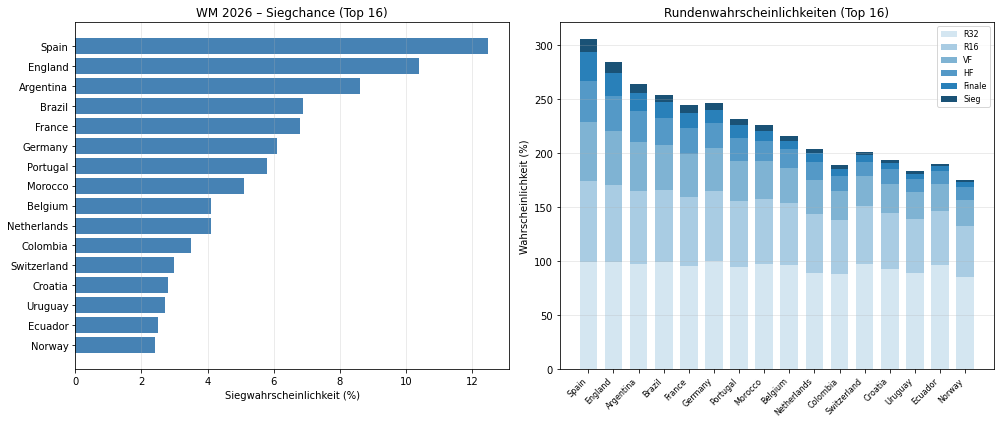

In [50]:
top16 = results_df.head(16)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linkes Panel: Siegwahrscheinlichkeit
axes[0].barh(top16["Team"][::-1], top16["Sieg %"][::-1], color="steelblue")
axes[0].set_xlabel("Siegwahrscheinlichkeit (%)")
axes[0].set_title("WM 2026 – Siegchance (Top 16)")
axes[0].grid(axis="x", alpha=0.3)

# Rechtes Panel: Stapeldiagramm der Rundenwahrscheinlichkeiten
stages = ["R32 %", "R16 %", "VF %", "HF %", "Finale %", "Sieg %"]
colors = ["#d4e6f1", "#a9cce3", "#7fb3d3", "#5499c7", "#2980b9", "#1a5276"]
bottom = np.zeros(len(top16))
for stage, color in zip(stages, colors):
    axes[1].bar(range(len(top16)), top16[stage], bottom=bottom,
                color=color, label=stage.replace(" %", ""), width=0.7)
    bottom += top16[stage].values
axes[1].set_xticks(range(len(top16)))
axes[1].set_xticklabels(top16["Team"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Wahrscheinlichkeit (%)")
axes[1].set_title("Rundenwahrscheinlichkeiten (Top 16)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 10.5 · Gruppenstaerke-Uebersicht

In [51]:
# Durchschnittlicher Elo je Gruppe
group_stats = []
for gname, teams in GROUPS.items():
    elos = [get_elo(model_name(t)) for t in teams]
    fav  = results_df[results_df["Team"].isin(teams)].iloc[0]["Team"]
    group_stats.append({
        "Gruppe":   gname,
        "Teams":    ", ".join(teams),
        "Elo Mittel": round(np.mean(elos)),
        "Elo Max":  round(max(elos)),
        "Favorit":  fav,
    })

pd.DataFrame(group_stats).set_index("Gruppe")

,Teams,Elo Mittel,Elo Max,Favorit
Gruppe,,,,
A,"Mexico, South Africa, South Korea, Czech Republic",1725,1786,South Korea
B,"Canada, Bosnia and Herzegovina, Qatar, Switzer...",1677,1755,Switzerland
C,"Brazil, Morocco, Haiti, Scotland",1785,1865,Brazil
D,"United States, Paraguay, Australia, Turkey",1772,1791,Turkey
E,"Germany, Curacao, Ivory Coast, Ecuador",1715,1833,Germany
F,"Netherlands, Japan, Sweden, Tunisia",1765,1839,Netherlands
G,"Belgium, Egypt, Iran, New Zealand",1751,1784,Belgium
H,"Spain, Cape Verde, Saudi Arabia, Uruguay",1766,1943,Spain
I,"France, Senegal, Iraq, Norway",1804,1898,France


## 11 · Nächste Ausbaustufe (Version 4)

- Automatische WM-Teilnehmerliste 2026 (48 Teams, 3 Gruppen à 4 Teams)
- Gruppenphase simulieren (Monte-Carlo, n=100.000)
- K.O.-Phase simulieren mit Elfmeter-Wahrscheinlichkeit
- Wettquoten-Features zur Kalibrierung
- Backtesting gegen historische WM-Ergebnisse